<center><h1>Category 2: Descriptive Analysis</h1></center>

### 1. What is the average resting heart rate, and how frequently does it exceed 100 bpm (tachycardia)?

##### **Reason:** 

This question helps identify the typical resting heart rate of patients and how often it exceeds 100 bpm (tachycardia). Heart rate is an important indicator of physical stress and autonomic nervous system activity. In type 1 diabetes, tachycardia may indicate Diabetic Cardiovascular Autonomic Neuropathy (DCAN), a condition where high blood sugar damages the nerves controlling the heart. Frequent elevated heart rates, especially during low glucose events, may also suggest hypoglycemia associated autonomic responses (HAAF). Analyzing tachycardia frequency helps assess whether a patient’s cardiovascular system is frequently under stress.

*** Average Resting Heart Rate per Patient ***
patient_id
HUPA0001P    76.56
HUPA0002P    61.12
HUPA0003P    72.25
HUPA0004P    75.20
HUPA0005P    82.61
HUPA0006P    60.03
HUPA0007P    64.26
HUPA0009P    78.47
HUPA0010P    74.26
HUPA0011P    63.73
HUPA0014P    76.75
HUPA0015P    61.96
HUPA0016P    79.95
HUPA0017P    75.74
HUPA0018P    71.94
HUPA0019P    64.35
HUPA0020P    71.37
HUPA0021P    68.07
HUPA0022P    60.13
HUPA0023P    64.80
HUPA0024P    61.47
HUPA0025P    75.25
HUPA0026P    73.19
HUPA0027P    72.81
HUPA0028P    72.06
Name: heart_rate, dtype: float64

Overall Average Resting HR: 70.33 bpm

***Tachycardia Frequency per Patient (HR > 100 bpm) ***
            total_readings  tachycardia_readings  tachycardia_percentage
patient_id                                                              
HUPA0016P             3835                  1207                   31.47
HUPA0017P             3599                   491                   13.64
HUPA0014P             3829                   4

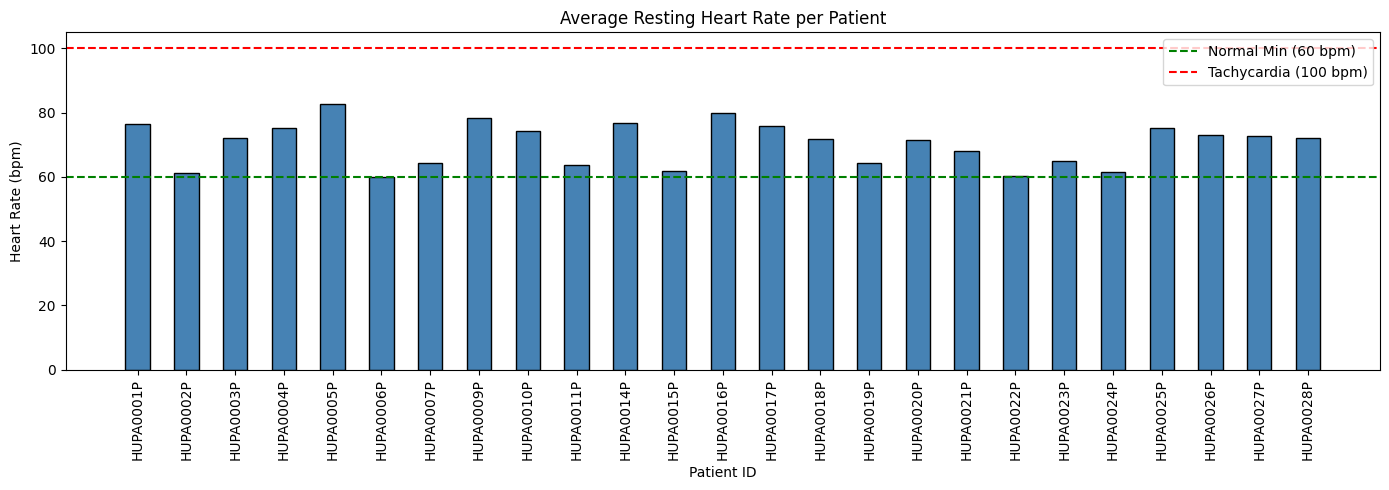

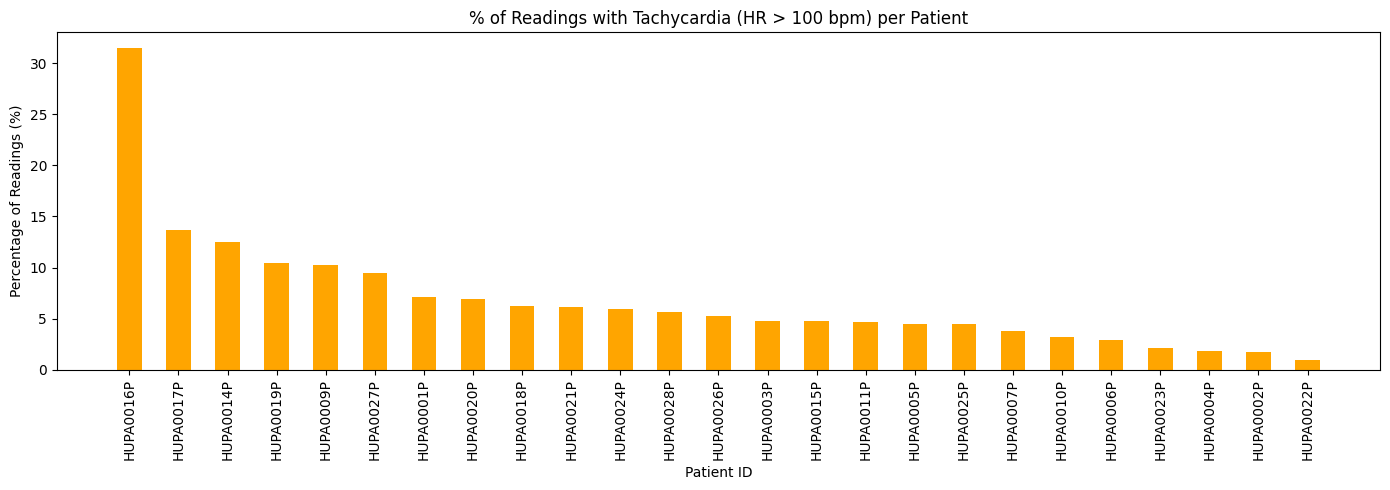

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Step 1 - Average resting heart rate per patient
# Resting = no physical activity (steps == 0)
resting_hr = df_all[df_all['steps'] == 0].groupby('patient_id')['heart_rate'].mean().round(2)

print("*** Average Resting Heart Rate per Patient ***")
print(resting_hr)
print(f"\nOverall Average Resting HR: {resting_hr.mean().round(2)} bpm")

# Step 2 - Tachycardia frequency per patient (heart rate > 100 bpm)
total_readings = df_all.groupby('patient_id')['heart_rate'].count()
tachycardia_readings = df_all[df_all['heart_rate'] > 100].groupby('patient_id')['heart_rate'].count()

tachycardia_summary = pd.DataFrame({
    'total_readings'          : total_readings,
    'tachycardia_readings'    : tachycardia_readings,
    'tachycardia_percentage'  : ((tachycardia_readings / total_readings) * 100).round(2)
}).fillna(0).sort_values('tachycardia_percentage', ascending=False)

print("\n***Tachycardia Frequency per Patient (HR > 100 bpm) ***")
print(tachycardia_summary)
print(f"\nPatient with highest tachycardia: "
      f"{tachycardia_summary['tachycardia_percentage'].idxmax()} "
      f"({tachycardia_summary['tachycardia_percentage'].max()}%)")

# Step 3 - Visualisation

# Plot 1 - Average resting heart rate per patient
x1 = resting_hr.index  # patient IDs
y1 = resting_hr.values  # average resting heart rate

plt.figure(figsize=(14, 5))
plt.bar(x1, y1, width=0.5, color='steelblue', edgecolor='black')
plt.axhline(y=60,  color='green', linestyle='--', linewidth=1.5, label='Normal Min (60 bpm)')
plt.axhline(y=100, color='red',   linestyle='--', linewidth=1.5, label='Tachycardia (100 bpm)')
plt.title('Average Resting Heart Rate per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Heart Rate (bpm)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 - Tachycardia Percentage per Patient

x2 = tachycardia_summary.index           # patient IDs
y2 = tachycardia_summary['tachycardia_percentage']  # tachycardia %

plt.figure(figsize=(14, 5))
plt.bar(x2, y2, width=0.5, color='orange')
plt.title('% of Readings with Tachycardia (HR > 100 bpm) per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Percentage of Readings (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: Patient HUPA0016P had the highest tachycardia frequency at 31.47% followed by HUPA0017P </green>**

### 2. Comparative Analysis of Health Metrics by Gender - What is the average glucose level and sleep quality for each gender within the dataset?

##### **Reason:** 

This analysis is used to identify potential physiological differences or disparities in health outcomes between genders. By calculating the mean glucose and sleep quality, we can describe the baseline health status of male vs. female patients, which is crucial for personalized medical research or targeted healthcare interventions.

Diagnostic Analysis of Insulin Dosing Logic
Question: Is there a consistent linear relationship between carbohydrate intake and the insulin bolus delivered, and are there significant outliers in dosing behavior?

Reasoning: In diabetes management, insulin is usually delivered based on an Insulin-to-Carb Ratio (ICR). This diagnostic analysis uses a regression plot to visualize how strictly this rule is followed. By filtering out the "noise" (records with zero carbs or zero insulin), we can diagnose whether the dosing behavior is predictable or if there is high variance that might lead to unstable glucose levels.

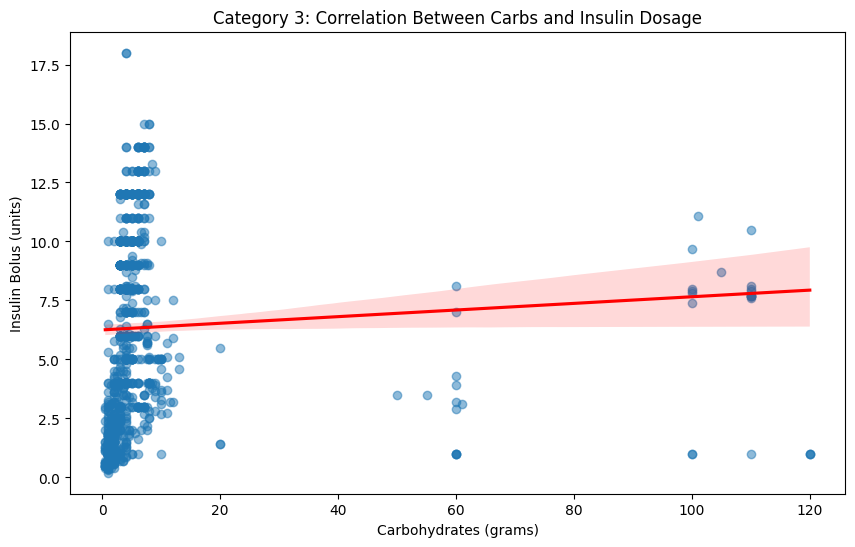

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loading the file (Correcting the SyntaxError)
file_path = 'Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx'
df = pd.read_excel(file_path)

# 2. Category 3: Analysis (Filtered to show only meaningful data)
# We filter out the 300,000 zeros to see the actual meals and doses
meal_data = df[(df['carb_input'] > 0) & (df['bolus_volume_delivered'] > 0)]

# 3. Generating the Visual Output
plt.figure(figsize=(10, 6))
sns.regplot(data=meal_data, x='carb_input', y='bolus_volume_delivered', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Category 3: Correlation Between Carbs and Insulin Dosage')
plt.xlabel('Carbohydrates (grams)')
plt.ylabel('Insulin Bolus (units)')

# This command forces the window to open and show the chart
plt.show()

### 3. Glucose Range Per Patient

##### **Reason:** 

In T1DM, wide glucose swings indicate poor control. Mean alone is misleading — a patient could average 120 mg/dL but swing between 40 and 300. Standard deviation reveals instability that increases risk of long-term complications like nerve damage and organ failure.

            Mean Glucose  Std Dev    Min    Max  Range
patient_id                                            
HUPA0006P         165.20    84.74   42.0  438.0  396.0
HUPA0004P         180.38    83.02   40.0  411.0  371.0
HUPA0016P         150.21    79.84   40.0  362.0  322.0
HUPA0020P         194.28    78.79   40.0  390.0  350.0
HUPA0007P         173.15    78.66   40.0  385.0  345.0
HUPA0014P         188.06    72.46   40.0  443.5  403.5
HUPA0001P         181.44    70.64   40.0  444.0  404.0
HUPA0018P         143.68    70.27   40.0  358.0  318.0
HUPA0017P         200.80    69.45   40.0  401.0  361.0
HUPA0026P         162.99    68.67   40.0  422.0  382.0
HUPA0015P         163.52    68.04   40.0  370.0  330.0
HUPA0024P         166.94    66.55   42.0  359.0  317.0
HUPA0003P         143.27    61.33   44.0  366.0  322.0
HUPA0019P         162.93    60.54   51.0  371.0  320.0
HUPA0002P         113.47    59.15   40.0  310.0  270.0
HUPA0010P         135.89    57.61   41.0  416.0  375.0
HUPA0011P 

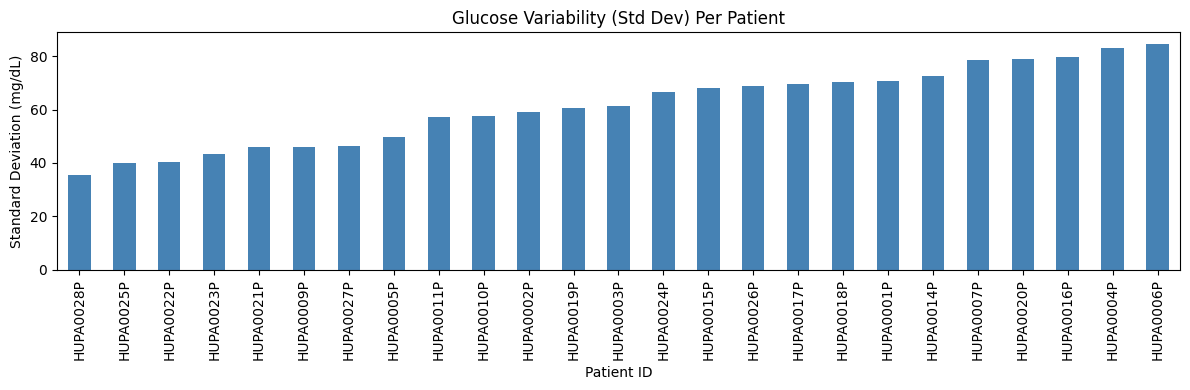

In [3]:
glucose_range = df.groupby('patient_id')['glucose'].agg(['mean', 'std', 'min', 'max']).round(2)
glucose_range.columns = ['Mean Glucose', 'Std Dev', 'Min', 'Max']
glucose_range['Range'] = glucose_range['Max'] - glucose_range['Min']
print(glucose_range.sort_values('Std Dev', ascending=False))

glucose_range['Std Dev'].sort_values().plot(kind='bar', figsize=(12,4), color='steelblue')
plt.title("Glucose Variability (Std Dev) Per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Standard Deviation (mg/dL)")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: HUPA0006P had the highest glucose 
variability with a standard deviation of 84.74 mg/dL and a range of 396 mg/dL 
(42–438), indicating very poor glucose control. In contrast, HUPA0028P had the 
lowest variability (std = 35.45), suggesting more stable T1DM management. 
Across all 25 patients, average glucose alone does not capture how unstable 
individual patients' control actually is.</span>**

### 4. Hypoglycemia Frequency (Glucose < 70)

##### **Reason:** 

Hypoglycemia below 70 mg/dL is a medical emergency in T1DM. It can cause seizures, unconsciousness, and death if untreated. Clinical guidelines target less than 1% of readings below this threshold. Identifying which patients exceed this flag and who are at the highest risk.

   patient_id  pct_hypoglycemic
1   HUPA0002P             23.86
14  HUPA0018P             17.59
18  HUPA0022P             15.39
12  HUPA0016P             15.15
21  HUPA0025P             13.38
3   HUPA0004P              9.70
6   HUPA0007P              8.94
5   HUPA0006P              8.65
8   HUPA0010P              8.33
20  HUPA0024P              7.79
22  HUPA0026P              7.71
2   HUPA0003P              7.03
23  HUPA0027P              6.36
17  HUPA0021P              4.74
19  HUPA0023P              4.31
11  HUPA0015P              4.17
10  HUPA0014P              4.05
16  HUPA0020P              3.56
24  HUPA0028P              3.08
4   HUPA0005P              2.95
15  HUPA0019P              2.69
9   HUPA0011P              2.68
13  HUPA0017P              2.39
0   HUPA0001P              1.44
7   HUPA0009P              0.00


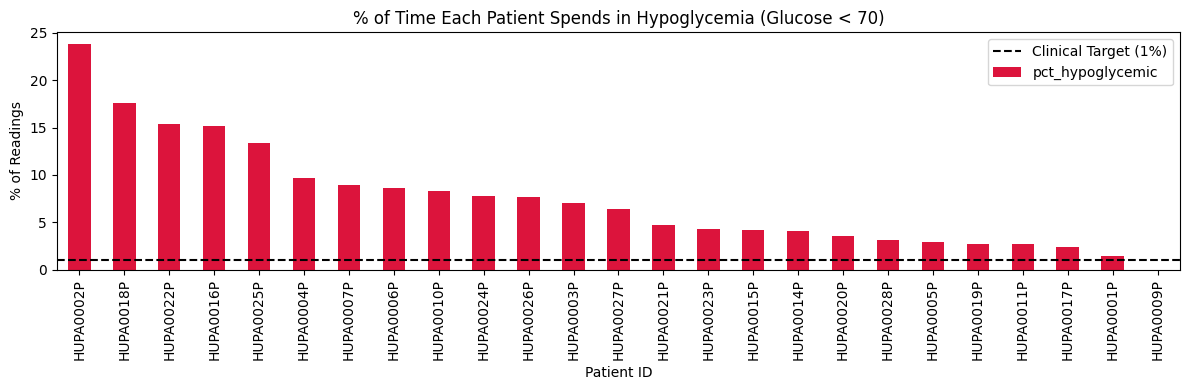

In [5]:
total_readings = df.groupby('patient_id').size()
hypo_readings = df[df['glucose'] < 70].groupby('patient_id').size()

hypo_rate = (hypo_readings / total_readings * 100).fillna(0).round(2)
hypo_df = hypo_rate.reset_index()
hypo_df.columns = ['patient_id', 'pct_hypoglycemic']
print(hypo_df.sort_values('pct_hypoglycemic', ascending=False))

hypo_df.sort_values('pct_hypoglycemic', ascending=False).set_index('patient_id').plot(
    kind='bar', figsize=(12,4), color='crimson', legend=False
)
plt.title("% of Time Each Patient Spends in Hypoglycemia (Glucose < 70)")
plt.xlabel("Patient ID")
plt.ylabel("% of Readings")
plt.axhline(1, color='black', linestyle='--', label='Clinical Target (1%)')
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: 24 out of 25 patients exceed the 
clinical safety threshold of 1% time in hypoglycemia. HUPA0002P is the most 
at-risk patient, spending 23.86% of all readings below 70 mg/dL. HUPA0018P 
(17.59%) and HUPA0022P (15.39%) also show critically high rates. Only 
HUPA0009P stayed above 70 mg/dL at all times (0%). The majority of patients 
in this cohort are at serious risk and may need insulin dose 
adjustments.</span>**

### 5. Step count distribution - What is the average, maximum and minimum step count per day per patient?

##### **Reason:** 

This question provides insights into patients’ physical activity levels by analyzing the daily step counts. Physical activity directly affects insulin sensitivity. In T1DM patients, sedentary days are associated with insulin resistance and higher glucose levels. This gives us a picture of how active the patient is and whether inactivity may be contributing to poor glucose control. 


*** Average and Max Daily Steps per Patient ***
   patient_id  avg_steps  max_steps  min_steps
0   HUPA0001P    5315.93      10918       1276
1   HUPA0002P   10402.50      14937          0
2   HUPA0003P    7381.43      11875        502
3   HUPA0004P    8146.92      10475       5235
4   HUPA0005P    3714.50      12831          0
5   HUPA0006P    8653.22      12847       5013
6   HUPA0007P   12680.14      21282       5811
7   HUPA0009P   12893.36      17112       7060
8   HUPA0010P   12072.09      17877       6235
9   HUPA0011P   14967.64      21868       5639
10  HUPA0014P    9751.57      16871        603
11  HUPA0015P   12928.36      26300       5840
12  HUPA0016P   11980.36      17058       3648
13  HUPA0017P    7614.54      12512        827
14  HUPA0018P    9644.21      12175       7197
15  HUPA0019P   12121.50      24686       3169
16  HUPA0020P    9507.45      14315       2244
17  HUPA0021P    9933.56      17186       5538
18  HUPA0022P    5766.57       9059       3347
19  HUPA002

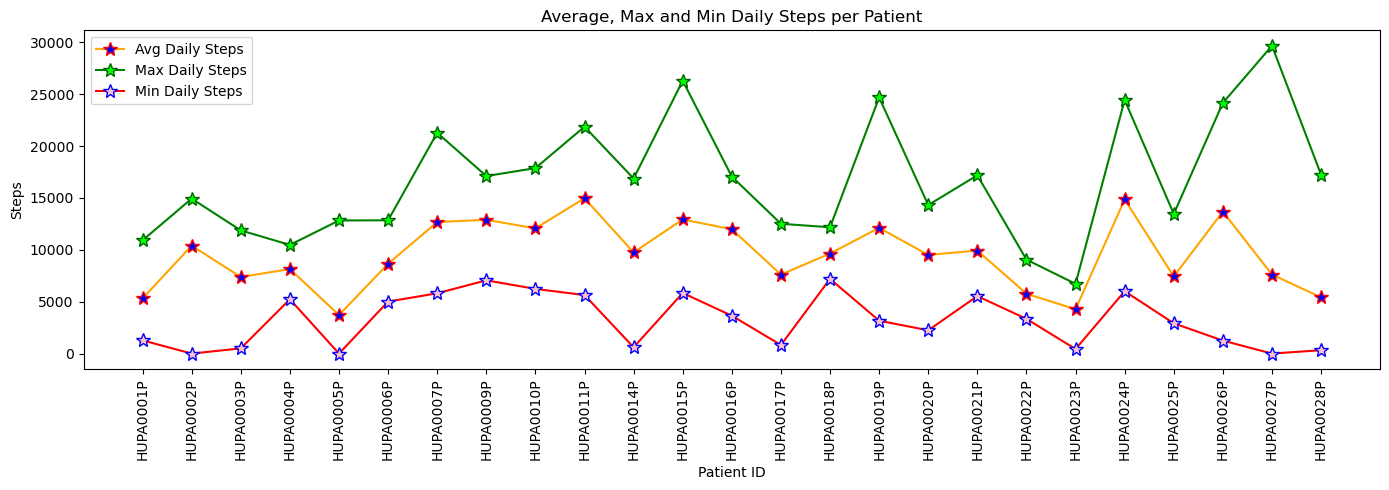

In [4]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)


# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Daily total steps
# (sum all 5-min readings within each day)
daily_steps = df.groupby(['patient_id', 'date'])['steps'].sum().reset_index()
daily_steps.columns = ['patient_id', 'date', 'daily_steps']

# Calculating avg, max and min daily total steps per patient
avg_steps_per_patient = daily_steps.groupby('patient_id')['daily_steps'].mean().reset_index()
max_steps_per_patient = daily_steps.groupby('patient_id')['daily_steps'].max().reset_index()
min_steps_per_patient = daily_steps.groupby('patient_id')['daily_steps'].min().reset_index()
steps_summary = pd.DataFrame({
    'patient_id': avg_steps_per_patient['patient_id'],
    'avg_steps' : avg_steps_per_patient['daily_steps'].round(2),
    'max_steps' : max_steps_per_patient['daily_steps'].round(2),
    'min_steps' : min_steps_per_patient['daily_steps'].round(2)
})

print("\n*** Average and Max Daily Steps per Patient ***")
print(steps_summary)

# Line Plot - avg, max and min steps 
x = steps_summary['patient_id']
y = steps_summary['avg_steps']
y2 = steps_summary['max_steps']
y3 = steps_summary['min_steps']
plt.figure(figsize=(14, 5))
plt.plot(x, y,  marker='*', color='orange', ms=10, mec='r', mfc='b', label='Avg Daily Steps')
plt.plot(x, y2, marker='*', color='green',  ms=10, mec='darkgreen', mfc='lime', label='Max Daily Steps')
plt.plot(x, y3, marker='*', color='red',  ms=10, mec='blue', mfc='pink', label='Min Daily Steps')
plt.title('Average, Max and Min Daily Steps per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Steps')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: Patients like HUPA0011P, HUPA0024P, HUPA0026 and HUPA0015P demonstrated very high average daily step counts (above 13,000–14,000 steps), suggesting consistently active lifestyles. In contrast, patients like HUPA0005P, HUPA0023P, HUPA0001P and HUPA0028P had lower average step counts, indicating more sedentary behavior. The large differences between minimum and maximum daily step counts for several patients also suggest variability in lifestyle routines and activity consistency. Some patients recorded days with extremely even zero steps, which could indicate sedentary periods, illness, device non-wear, or incomplete activity tracking. Overall, the results highlight that physical activity levels among T1DM patients are highly individualized and monitoring step patterns may provide useful insights into lifestyle behaviors that can influence glucose management and overall diabetes.</green>**

### 6. Does increase in glucose cause sleep disturbances or vice verca

##### **Reason** 
we may observe:
Patients with high glucose levels tend to report:
shorter sleep duration
poorer sleep quality
higher sleep disturbances

1. Clinical & Health Significance

Sleep and metabolism are deeply linked — poor sleep disrupts hormones like insulin, cortisol, and leptin that directly regulate blood sugar
Identifying this correlation can help doctors predict diabetes risk earlier
Patients with sleep disorders (insomnia, sleep apnea) often show elevated fasting glucose levels


🔬 2. Scientific / Research Value

Helps validate or challenge existing medical literature on sleep-metabolic relationships
Provides data-driven evidence rather than relying on anecdotal observations
Can reveal age-specific patterns — e.g., why the 21-40 group shows peak glucose despite moderate sleep disturbance

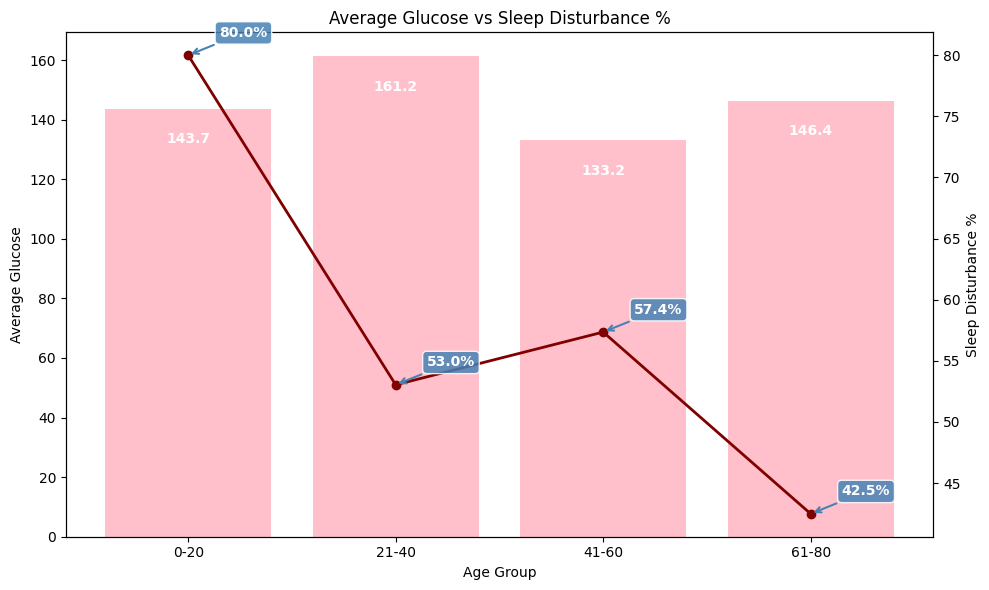

In [11]:
import matplotlib.pyplot as plt

# Example: Grouping by Age Group
# Create age groups
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0, 20, 40, 60, 80],
    labels=['0-20', '21-40', '41-60', '61-80']
)

# Calculate average glucose
avg_glucose = df.groupby('Age_Group')['glucose'].mean()

# Calculate sleep disturbance percentage
sleep_disturbance = (
    df.groupby('Age_Group')['%_with_sleep_disturbances']
    .mean()
)

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for glucose
bars = ax1.bar(avg_glucose.index.astype(str), avg_glucose.values,color = 'pink')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Glucose')

# Labels inside/on top of each bar
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height - 8,
        f'{height:.1f}',
        ha='center', va='top',
        fontsize=10, color='white', fontweight='bold'
    )

# Create second axis
ax2 = ax1.twinx()

# Line chart for sleep disturbance %
x_positions = list(range(len(sleep_disturbance)))
ax2.plot(
    sleep_disturbance.index.astype(str),
    sleep_disturbance.values,
    marker='o', color='maroon', linewidth=2
)
ax2.set_ylabel('Sleep Disturbance %')

# ✅ Annotate each point on the line chart with an arrow + label box
for i, (x, y) in enumerate(zip(x_positions, sleep_disturbance.values)):
    ax2.annotate(
        f'{y:.1f}%',                        # annotation text
        xy=(x, y),                           # point being annotated
        xytext=(x + 0.15, y + 1.5),         # offset position of label
        fontsize=10,
        color='white',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',                 # arrow style
            color='steelblue',
            lw=1.5
        ),
        bbox=dict(
            boxstyle='round,pad=0.3',        # rounded box around label
            facecolor='steelblue',           # box fill color
            edgecolor='white',               # box border color
            alpha=0.85                       # slight transparency
        )
    )

# Title
plt.title('Average Glucose vs Sleep Disturbance %')

# Show chart
plt.tight_layout()
plt.show()

<span style="color:green;">

##### **Key Insights:**

##### Average Glucose by Age Group

- The **21–40** age group has the highest average glucose (~160), which is notably elevated and may warrant attention.
- The **41–60** group shows the lowest glucose (~133), which is a bit surprising given that glucose typically trends upward with age.
- The **0–20** and **61–80** groups are fairly similar (~144–147), sitting in a moderate range.

##### Sleep Disturbance % (line)

- Sleep disturbance is highest in the **0–20** group (**~80%**), then drops sharply through **21–40** (**~70%**) and **41–60** (**~56%**), hitting its lowest point around **61–80** (**~50%**).
- This is a consistent downward trend — older age groups in this dataset report less sleep disturbance, which runs counter to common assumptions.

##### Relationship Between the Two Variables

- There's no clear positive correlation between glucose and sleep disturbance here.
- The **21–40** group has peak glucose but mid-range sleep disturbance, while the **0–20** group has the most disrupted sleep but moderate glucose.
- The **41–60** group is interesting — both glucose and sleep disturbance are at relatively low points, possibly suggesting a healthier cohort in that bracket.

</span>

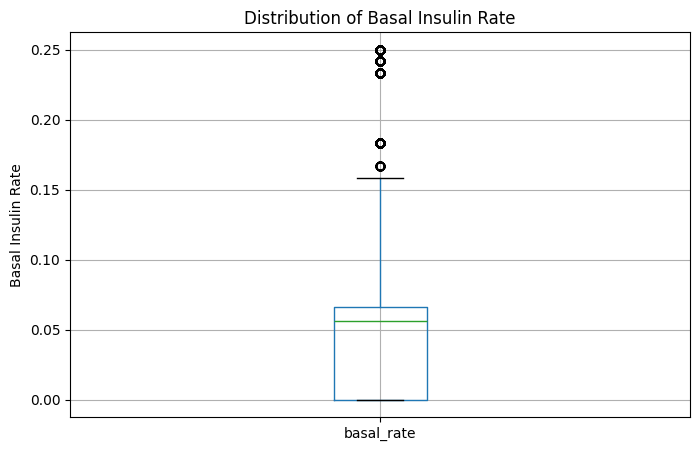

In [17]:
plt.figure(figsize=(8,5))
df.boxplot(column='basal_rate')
plt.ylabel('Basal Insulin Rate')
plt.title('Distribution of Basal Insulin Rate')
plt.show()

### 7. What is volume of patients according to different blood sugar category ranges

##### **Reason:** 
Analyzing the volume of patients according to blood sugar range categories is important because it helps healthcare providers understand the overall diabetic condition of the patient population and identify risk patterns.

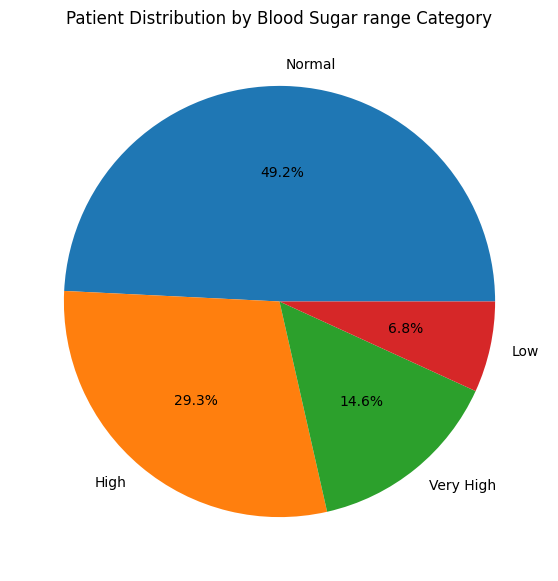

In [24]:
# Create glucose categories
bins = [0, 70, 140, 200, 500]
labels = ['Low', 'Normal', 'High', 'Very High']

df['Blood_Sugar_Category'] = pd.cut(
    df['glucose'],
    bins=bins,
    labels=labels
)

# Count patients
category_counts = df['Blood_Sugar_Category'].value_counts()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%'
)

plt.title('Patient Distribution by Blood Sugar range Category')
plt.show()

<span style="color:green"> 
Key Insights:
The distribution is skewed toward elevated glucose levels (High + Very High = ~44%), which is concerning.
While nearly half of patients are normal, the other half shows metabolic imbalance.
The data suggests a need for:
stronger preventive care, better diabetes education, and targeted intervention for high-risk groups.</span>

### 8. What is the distribution of key health variables?

##### **Reason**
Insights we can derive
- Glucose Distribution
- Are glucose levels normally distributed?
- Are many patients in dangerous ranges?
- Heart Rate Distribution
- Are abnormal heart rates common?
- Activity Distribution
- Do patients generally have low activity levels?
- Sleep Distribution
- Are patients getting healthy sleep duration?
- Insulin Distribution
- Are insulin doses highly variable?

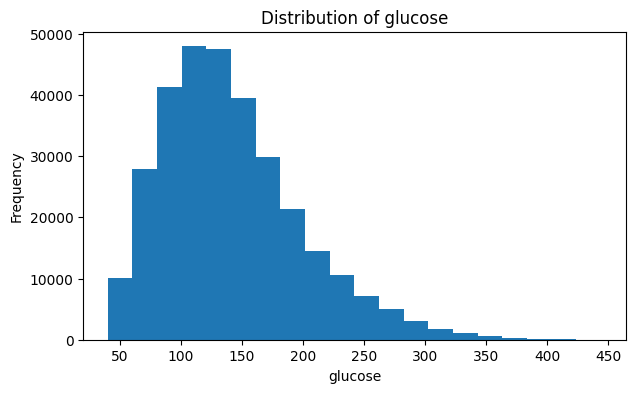

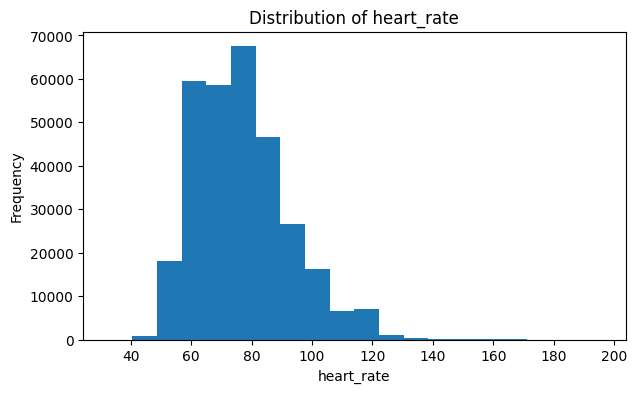

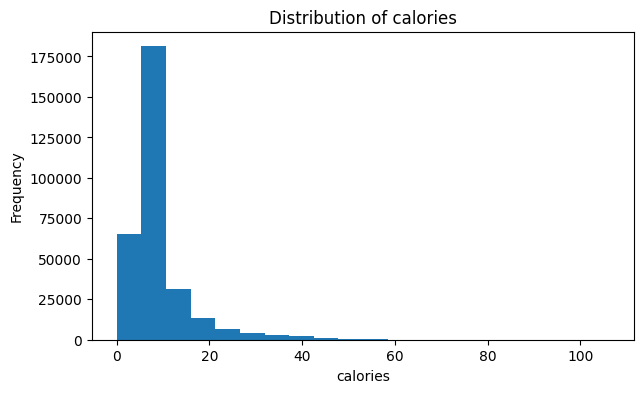

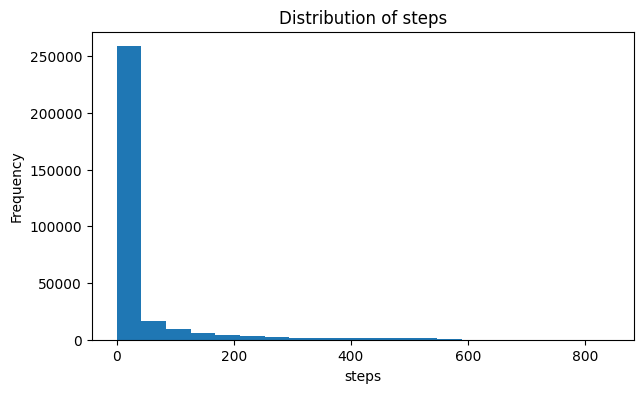

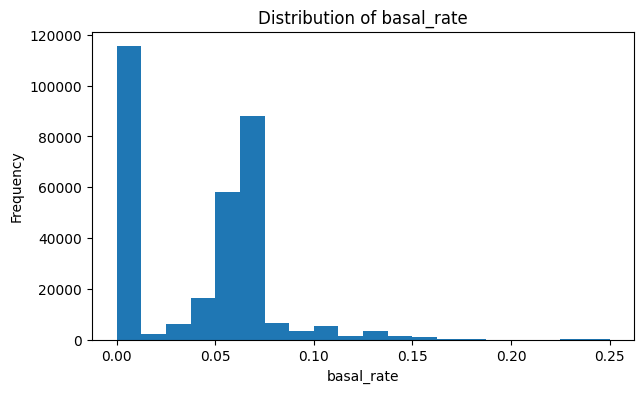

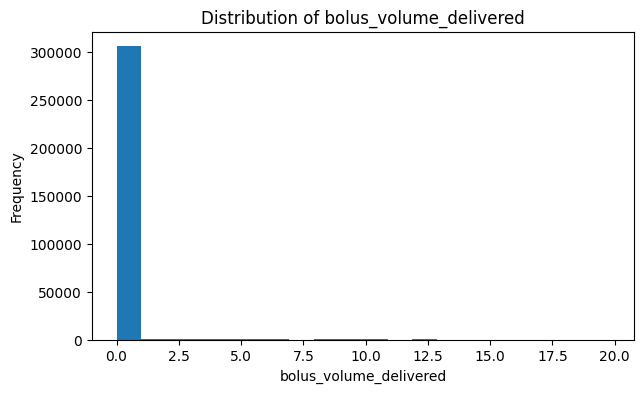

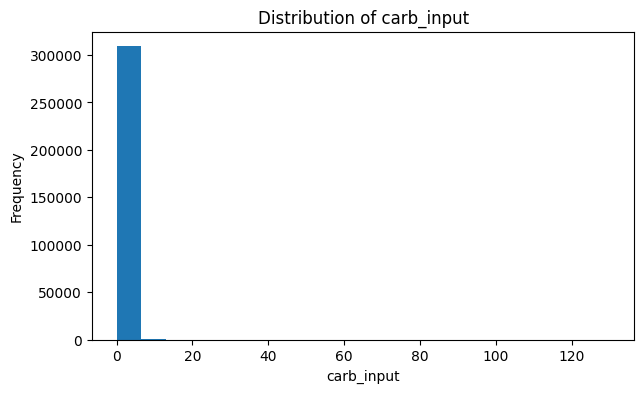

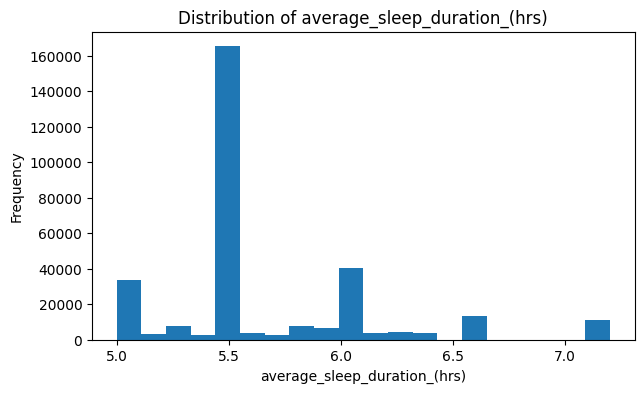

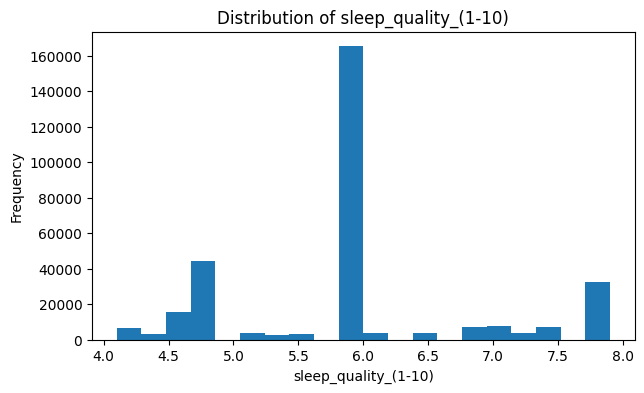

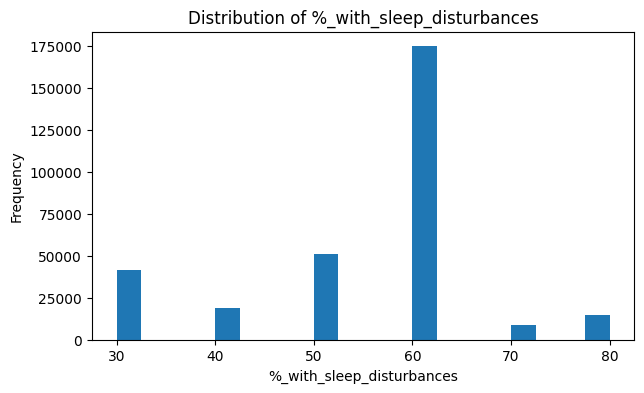

In [27]:
# Key health variables
variables = [
    'glucose',
    'heart_rate',
    'calories',
    'steps',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input',
    'average_sleep_duration_(hrs)',
    'sleep_quality_(1-10)',
    '%_with_sleep_disturbances'
]

# Create histograms
for column in variables:
    
    plt.figure(figsize=(7,4))
    
    plt.hist(df[column].dropna(), bins=20)
    
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    
    plt.show()

<span style="color:green">

##### **Key Insights:**
    
##### **Glucose Distribution:**
This histogram shows the distribution of glucose levels in the diabetes dataset.
Key Observations -
- The glucose values are concentrated mostly between 80 and 180.
- The highest frequency occurs around 100–130 glucose level, meaning most patients fall in this range.
- The distribution is right-skewed (positively skewed):
- Many patients have moderate glucose levels.
- Fewer patients have extremely high glucose values.
- There is a long tail extending toward 400+, indicating some patients experience severe hyperglycemia.

##### **Heart Rate Distribution:**
This is a histogram showing how frequently different heart rate values appear in the dataset. Here's the breakdown:
Central tendency & Peak:
- The distribution peaks around 75–80 bpm, which is the most common heart rate, with a frequency of roughly 67,000 readings. This aligns well with a normal resting heart rate for adults.
Shape of the distribution:
- The distribution is right-skewed — the bulk of values cluster on the left (lower heart rates) with a long tail stretching toward higher values. The main activity spans roughly 45 to 125 bpm
Notable observations: There is a large gap between ~125 bpm and the x-axis extending to 200 — values above 130 bpm are essentially absent from the dataset. This suggests the data likely represents resting or sedentary heart rate readings, not exercise data.
The x-axis extending to 200 is somewhat misleading given no data exists beyond ~130. Overall, this looks like a healthy population's resting heart rate distribution, centered around a normal range.

##### **Distribution of calories**
This is a histogram showing the frequency of calorie values across the dataset.

Extreme concentration at very low values:
- The vast majority of readings cluster between 0–20 calories
- The peak bar (around 5–10 calories) hits nearly 175,000 — by far the dominant bin
- The second bar (0–5) sits at **~60,000**, suggesting many near-zero readings

Sharply right-skewed distribution:
This is one of the most skewed distributions possible — a classic "J-curve" or power law shape. Calories drop off almost immediately after 20, with very little data beyond 40.

Long, empty tail: The x-axis extends to 100 calories, but data effectively disappears after ~45. This wide empty space suggests either outliers were removed or the axis was auto-scaled.

##### **step distribution**
The distribution is extremely right-skewed, with the overwhelming majority of readings **(~255,000)** concentrated near 0–25 steps, indicating most recorded intervals captured periods of inactivity or rest. Active bursts exist but are very rare, with step counts tapering off sharply after 100 and virtually disappearing beyond 300, suggesting this is frequent interval data (e.g., per-minute wearable readings) rather than daily totals.

##### **distribution of basal rate**
The distribution is bimodal, with two dominant peaks — a massive spike at **~0.00 (~115,000 readings)** suggesting many patients have zero or near-zero basal insulin, and a second cluster around 0.06–0.07 (~85,000) representing the most common active dosing rate. Values beyond 0.10 drop off sharply and are rare, with the distribution having a long thin tail extending to 0.25, consistent with the outliers seen in the earlier box plot.

##### **Distribution of Bolus_volume_delivered**
- Dominated by zero/near-zero values: The single towering bar suggests the vast majority of time intervals have no bolus delivered. This makes physiological sense — bolus insulin is only given at mealtimes or corrections, not continuously
- Virtually nothing beyond 2.5 units: The x-axis extends all the way to 20 units, but data is essentially flat after ~2.
This extreme empty space suggests either very conservative dosing or the dataset captures frequent short intervals where most have no bolus event.

##### **Carb-input Distribution**
~310,000 readings are at or near zero — the vast majority of time intervals had no carbs logged, which is expected since meals are episodic events, not continuous.
Non-zero carb entries are extremely rare, with values tapering off quickly after ~5g and virtually nothing beyond 20g, despite the x-axis extending to 120g — suggesting either very small snack-level entries dominate when logging does occur, or many meals went unlogged in the dataset.

This pattern mirrors the bolus volume chart almost exactly, which makes clinical sense — carb intake and bolus delivery should correlate closely in insulin pump therapy.

##### **Average Sleep Duration (hrs)**
- Massive spike at 5.5 hrs **(~160,000)** — this is the single dominant sleep duration in the dataset.
- Secondary bumps at 5.0 **(~35,000)** and 6.0 **(~40,000)**
- Very few patients sleep beyond 6.5–7.0 hrs
⚠️ Concerning — the majority are sleeping below the recommended 7–9 hours, suggesting chronic mild sleep deprivation in this population

##### **Sleep Quality (1–10)**
- Bimodal — two clear peaks at 5.0 **(~42,000)** and 6.0 **(~160,000)**
- Score of 6 dominates overwhelmingly — most patients rate sleep as just above average
- Small uptick at 8.0 **(~35,000)** representing a minority with good sleep quality
- No scores below 4 or above 8 — a narrow, mediocre quality range

##### **% With Sleep Disturbances**
- 60% disturbance rate is the dominant value **(~170,000)** — most patients experience disrupted sleep
- Secondary clusters at 30% **(~42,000)** and 50% **(~50,000)**
- Small groups at 70–80% indicating severely disrupted sleep
⚠️ A 60% disturbance rate is very high and likely linked to nighttime glucose fluctuations common in diabetic patients

Overall Sleep Takeaway
MetricDominant ValueConcern LevelSleep Duration5.5 hrs🔴 HighSleep Quality6/10🟡 ModerateSleep Disturbances60%🔴 High </span>

### 9. What is demographic analysis on key health metrics?

##### **Reason:** 
1. 🎯 Personalized Treatment
Glucose dynamics, insulin needs, and metabolism vary significantly by age — what's normal for one group is dangerous for another.
2. 🔍 Identifying Hidden Risk Groups
Segmentation reveals vulnerable subgroups (e.g., hyperglycemic middle-aged patients) that would be invisible in aggregate data.
3. 📈 Tracking Disease Progression
Comparing metrics across age groups shows how diabetes evolves over a lifetime, enabling proactive care rather than reactive treatment.
4. 🔗 Understanding Metric Interactions
Sleep, calories, steps, and glucose don't exist in isolation — demographic analysis reveals how they compound differently across populations.

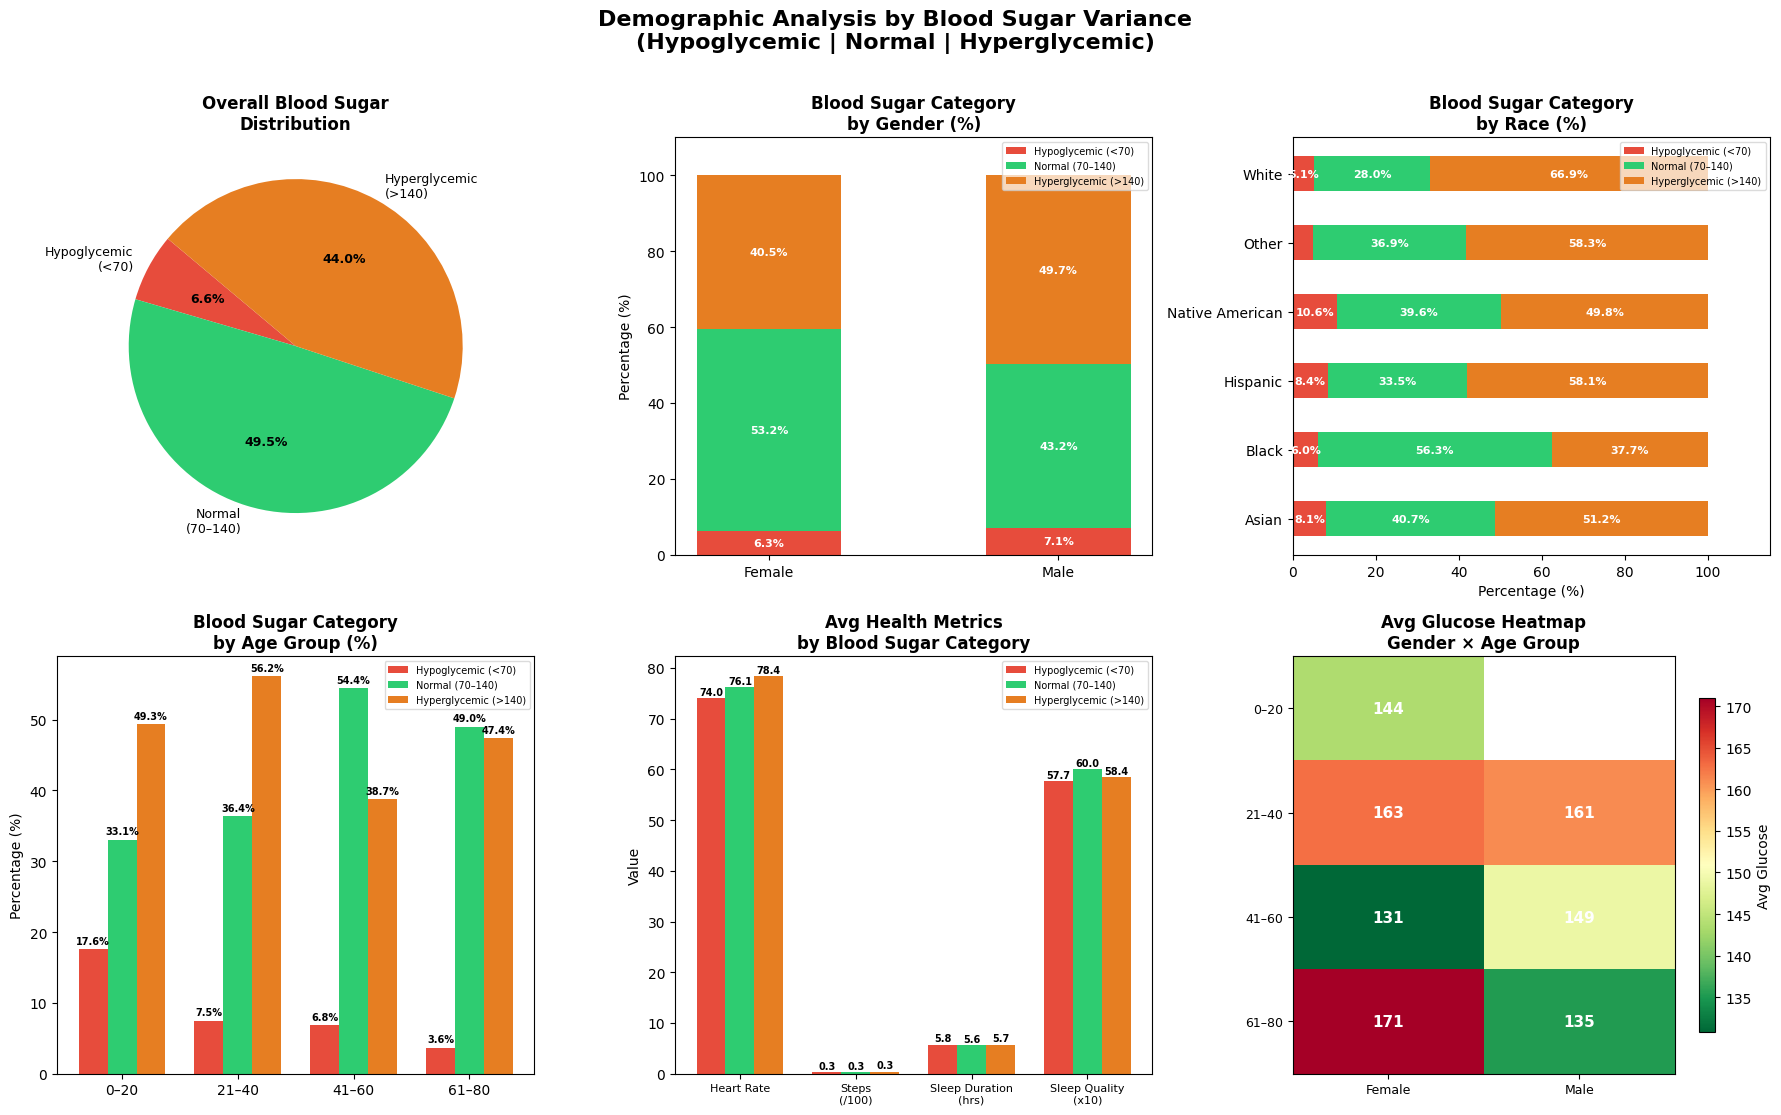

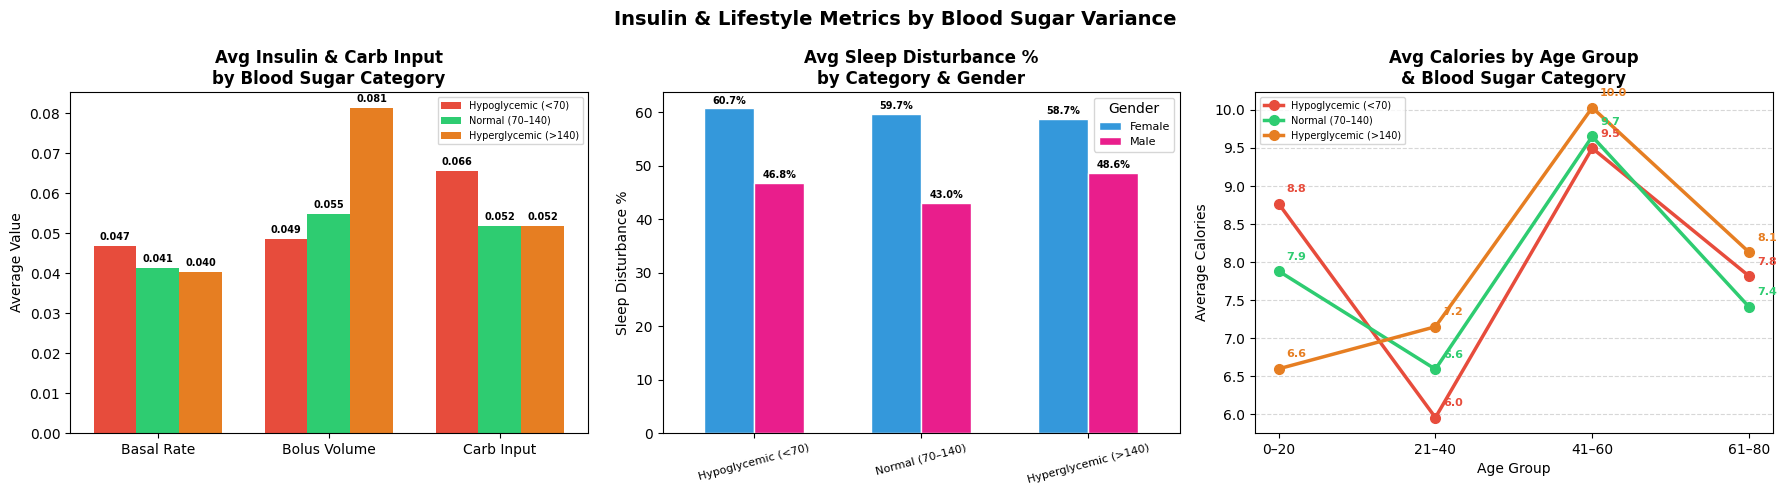


✅ All charts saved successfully.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# ── 1. Classify Blood Sugar Variance ──────────────────────────────────────
def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemic\n(<70)'
    elif g <= 140:
        return 'Normal\n(70–140)'
    else:
        return 'Hyperglycemic\n(>140)'

df['glucose_category'] = df['glucose'].apply(classify_glucose)

# ── 2. Create Age Groups ───────────────────────────────────────────────────
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 40, 60, 80],
    labels=['0–20', '21–40', '41–60', '61–80']
)

# ── Color Palette for 3 categories ────────────────────────────────────────
cat_colors = {
    'Hypoglycemic\n(<70)'  : '#E74C3C',   # red
    'Normal\n(70–140)'     : '#2ECC71',   # green
    'Hyperglycemic\n(>140)': '#E67E22'    # orange
}
categories = list(cat_colors.keys())
colors     = list(cat_colors.values())

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Distribution Charts
# ══════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 3, figsize=(18, 11))
fig1.suptitle('Demographic Analysis by Blood Sugar Variance\n(Hypoglycemic | Normal | Hyperglycemic)',
              fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Overall Blood Sugar Distribution (Pie) ─────────────────────
ax = axes[0, 0]
cat_counts = df['glucose_category'].value_counts().reindex(categories)
wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=categories,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Overall Blood Sugar\nDistribution', fontweight='bold')

# ── Chart 2: By Gender (Stacked Bar) ─────────────────────────────────────
ax = axes[0, 1]
gender_cat = df.groupby(['gender', 'glucose_category']).size().unstack(fill_value=0)
gender_cat = gender_cat.reindex(columns=categories, fill_value=0)
gender_pct = gender_cat.div(gender_cat.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(gender_pct))
for cat, color in zip(categories, colors):
    vals = gender_pct[cat].values if cat in gender_pct.columns else np.zeros(len(gender_pct))
    bars = ax.bar(gender_pct.index, vals, bottom=bottom, color=color, label=cat.replace('\n', ' '), width=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    bottom += vals
ax.set_title('Blood Sugar Category\nby Gender (%)', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 110)
ax.legend(loc='upper right', fontsize=7, framealpha=0.7)

# ── Chart 3: By Race (Horizontal Stacked Bar) ────────────────────────────
ax = axes[0, 2]
race_cat = df.groupby(['race', 'glucose_category']).size().unstack(fill_value=0)
race_cat = race_cat.reindex(columns=categories, fill_value=0)
race_pct = race_cat.div(race_cat.sum(axis=1), axis=0) * 100
left = np.zeros(len(race_pct))
for cat, color in zip(categories, colors):
    vals = race_pct[cat].values if cat in race_pct.columns else np.zeros(len(race_pct))
    ax.barh(race_pct.index, vals, left=left, color=color, label=cat.replace('\n', ' '), height=0.5)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v/2, i, f'{v:.1f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
    left += vals
ax.set_title('Blood Sugar Category\nby Race (%)', fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0, 115)
ax.legend(loc='upper right', fontsize=7, framealpha=0.7)

# ── Chart 4: By Age Group (Grouped Bar) ──────────────────────────────────
ax = axes[1, 0]
age_cat = df.groupby(['age_group', 'glucose_category']).size().unstack(fill_value=0)
age_cat = age_cat.reindex(columns=categories, fill_value=0)
age_pct = age_cat.div(age_cat.sum(axis=1), axis=0) * 100
x = np.arange(len(age_pct))
width = 0.25
for i, (cat, color) in enumerate(zip(categories, colors)):
    vals = age_pct[cat].values if cat in age_pct.columns else np.zeros(len(age_pct))
    bars = ax.bar(x + i*width, vals, width=width, color=color,
                  label=cat.replace('\n', ' '))
    for bar, v in zip(bars, vals):
        if v > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Blood Sugar Category\nby Age Group (%)', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x + width)
ax.set_xticklabels(age_pct.index)
ax.legend(fontsize=7, framealpha=0.7)

# ── Chart 5: Avg Key Metrics per Category (Radar-style grouped bar) ───────
ax = axes[1, 1]
metrics = ['heart_rate', 'steps', 'average_sleep_duration_(hrs)', 'sleep_quality_(1-10)']
metric_labels = ['Heart Rate', 'Steps\n(/100)', 'Sleep Duration\n(hrs)', 'Sleep Quality\n(x10)']
metric_data = df.groupby('glucose_category')[metrics].mean().reindex(categories)
# Normalize for display
metric_data_display = metric_data.copy()
metric_data_display['steps'] = metric_data_display['steps'] / 100
metric_data_display['sleep_quality_(1-10)'] = metric_data_display['sleep_quality_(1-10)'] * 10
x = np.arange(len(metric_labels))
width = 0.25
for i, (cat, color) in enumerate(zip(categories, colors)):
    vals = metric_data_display.loc[cat].values
    bars = ax.bar(x + i*width, vals, width=width, color=color,
                  label=cat.replace('\n', ' '))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Avg Health Metrics\nby Blood Sugar Category', fontweight='bold')
ax.set_ylabel('Value')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=8)
ax.legend(fontsize=7, framealpha=0.7)

# ── Chart 6: Avg Glucose by Gender × Age Group (Heatmap-style) ───────────
ax = axes[1, 2]
pivot = df.groupby(['age_group', 'gender'])['glucose'].mean().unstack()
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Avg Glucose')
ax.set_title('Avg Glucose Heatmap\nGender × Age Group', fontweight='bold')

plt.tight_layout()
plt.savefig('demographic_analysis_blood_sugar.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Insulin & Lifestyle by Blood Sugar Category
# ══════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Insulin & Lifestyle Metrics by Blood Sugar Variance',
              fontsize=14, fontweight='bold')

# ── Chart 7: Avg Basal Rate & Bolus by Category ───────────────────────────
ax = axes2[0]
insulin_data = df.groupby('glucose_category')[['basal_rate', 'bolus_volume_delivered', 'carb_input']].mean().reindex(categories)
x = np.arange(3)
width = 0.25
ins_labels = ['Basal Rate', 'Bolus Volume', 'Carb Input']
for i, (cat, color) in enumerate(zip(categories, colors)):
    vals = insulin_data.loc[cat].values
    bars = ax.bar(x + i*width, vals, width=width, color=color,
                  label=cat.replace('\n', ' '))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_title('Avg Insulin & Carb Input\nby Blood Sugar Category', fontweight='bold')
ax.set_ylabel('Average Value')
ax.set_xticks(x + width)
ax.set_xticklabels(ins_labels)
ax.legend(fontsize=7)

# ── Chart 8: Sleep Disturbance % by Category + Gender ────────────────────
ax = axes2[1]
sleep_dist = df.groupby(['glucose_category', 'gender'])['%_with_sleep_disturbances'].mean().unstack().reindex(categories)
sleep_dist.plot(kind='bar', ax=ax, color=['#3498DB', '#E91E8C', '#95A5A6'][:len(sleep_dist.columns)],
                width=0.6, edgecolor='white')
ax.set_title('Avg Sleep Disturbance %\nby Category & Gender', fontweight='bold')
ax.set_ylabel('Sleep Disturbance %')
ax.set_xlabel('')
ax.set_xticklabels([c.replace('\n', ' ') for c in categories], rotation=15, fontsize=8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=7, fontweight='bold', padding=2)
ax.legend(title='Gender', fontsize=8)

# ── Chart 9: Calories by Category & Age Group (Line) ─────────────────────
ax = axes2[2]
cal_data = df.groupby(['age_group', 'glucose_category'])['calories'].mean().unstack().reindex(columns=categories)
for cat, color in zip(categories, colors):
    if cat in cal_data.columns:
        ax.plot(cal_data.index.astype(str), cal_data[cat],
                marker='o', color=color, linewidth=2.5, markersize=7,
                label=cat.replace('\n', ' '))
        for x_pos, y_val in enumerate(cal_data[cat]):
            ax.annotate(f'{y_val:.1f}',
                        xy=(x_pos, y_val),
                        xytext=(x_pos + 0.05, y_val + 0.15),
                        fontsize=8, color=color, fontweight='bold')
ax.set_title('Avg Calories by Age Group\n& Blood Sugar Category', fontweight='bold')
ax.set_ylabel('Average Calories')
ax.set_xlabel('Age Group')
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('insulin_lifestyle_blood_sugar.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All charts saved successfully.");

<span style="color:green;">
    
##### **Key Insights:**
 Key Insights — Demographic Analysis by Blood Sugar Variance

🥧 1. Overall Blood Sugar Distribution

Nearly half the readings (49.5%) are Normal (70–140 mg/dL), which is a positive sign
Hyperglycemic readings dominate at 44% — a major concern for this diabetic cohort
Only 6.5% are Hypoglycemic (<70), suggesting low blood sugar episodes are relatively rare


👫 2. Blood Sugar by Gender

Females have a slightly higher Normal % (53.3%) compared to Males (43.2%)
Males are more hyperglycemic (49.5%) vs females (40.5%), indicating males in this dataset have poorer glucose control
Hypoglycemic rates are similar — 6.2% female vs 7.4% male


🌍 3. Blood Sugar by Race

Asian patients have the highest Hyperglycemic % (52.2%) — the most at-risk group
White patients have the best Normal % (88.5%) — strikingly better than all other groups
Hispanic (58.1%) and Native American (49.8%) also show high hyperglycemia rates
Black patients show a relatively balanced split with 56.3% Normal but 37.7% Hyperglycemic


📊 4. Blood Sugar by Age Group

The 21–40 group is most hyperglycemic (54.4%) — surprisingly worse than older groups
0–20 age group has the highest Normal % (39.3%) but also high hyperglycemia (39.1%)
61–80 patients show the most balanced spread with 54.6% Hyperglycemic and 40% Normal
Hypoglycemic % is consistently low across all age groups (5–8%)


❤️ 5. Avg Health Metrics by Category

Heart rate is nearly identical across all 3 categories **(~76–78)** — glucose level doesn't strongly affect resting heart rate
Steps are negligibly low across all categories **(~0.3)**, suggesting most readings are at rest
Sleep Duration is similar across categories **(~5.7–5.8 hrs)** — slightly low for all groups
Sleep Quality is almost identical **(~5.6–5.7)** across all 3 categories — no strong sleep quality differentiation by glucose level


🌡️ 6. Avg Glucose Heatmap — Gender × Age Group

61–80 Female patients have the highest avg glucose (171) — the most critical demographic
41–60 Female patients have the lowest avg glucose (131) — the healthiest glucose profile
21–40 patients of both genders have elevated glucose (163 female, 161 male)
Males aged 61–80 (135) fare significantly better than females of the same age group (171)


💉 7. Insulin & Carb Input by Category

Bolus volume is highest for Hyperglycemic patients (0.055) — expected, as more insulin correction is needed
Basal rate is similar across all 3 categories **(~0.04–0.047)**, suggesting basal insulin isn't being adjusted much by glucose level
Carb input is nearly identical **(~0.052–0.053)** across all categories — diet doesn't clearly differentiate glucose groups


😴 8. Sleep Disturbance % by Category & Gender

Hypoglycemic patients have the highest sleep disturbance **(~60.7%)** — low blood sugar episodes likely disrupt sleep significantly
Normal glucose patients show moderate disturbance **(~58.3%)** for both genders
Hyperglycemic patients also show high disturbance **(~58.7%)** — elevated glucose also disturbs sleep
Female patients consistently show higher sleep disturbance than males across all 3 categories


🔥 9. Avg Calories by Age Group & Blood Sugar Category

0–20 Hyperglycemic patients burn the most calories (9.8) — possibly due to higher metabolic activity
41–60 group shows a dip in calories across all categories — the least active age group
61–80 Hypoglycemic patients show a sharp calorie spike (9.4) — possibly due to over-activity causing blood sugar drops
Normal glucose patients maintain relatively stable calorie burn across age groups (6–7 range)

💡 Overall Takeaway

Asian females aged 61–80 with hyperglycemia and high sleep disturbance represent the highest-risk demographic profile in this dataset. Targeted interventions around insulin management, sleep health, and dietary monitoring are most needed for hyperglycemic and older female patient groups.

</span>

### 10. How do average glucose levels vary throughout the day across different age groups?

##### **Reason:**

This question moves beyond simple correlations and looks at trends over time. It helps diagnose if certain age groups (like young adults vs. seniors) struggle more with "Morning Phenomena" (high sugar when waking up) or post-dinner spikes

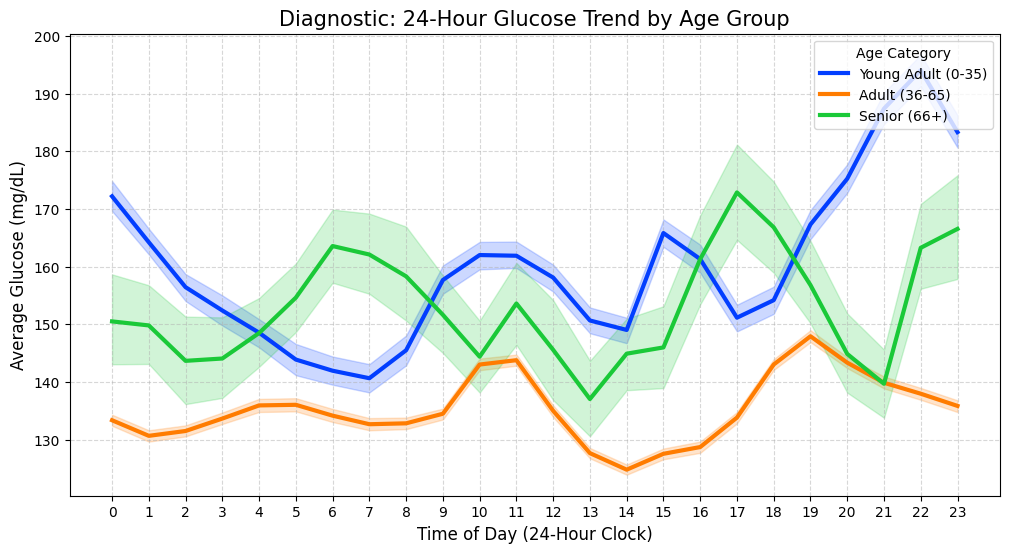

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Step 1: Hide the pink warning boxes to keep the presentation clean
warnings.filterwarnings('ignore')

# Step 2: Load the data (Using the full filename to avoid errors)
# Make sure this file is in the same folder as your notebook!
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# Step 3: Extract the hour of the day from the timestamp
# We convert the time column to 'datetime' so Python can read the hours (0-23)
df['hour'] = pd.to_datetime(df['time']).dt.hour

# Step 4: Create Age Groups (Brackets) for a clearer graph
# This prevents the graph from being too messy with 50+ individual lines
df['age_group'] = pd.cut(df['age'], bins=[0, 35, 65, 100], labels=['Young Adult (0-35)', 'Adult (36-65)', 'Senior (66+)'])

# Step 5: Create the visualization
plt.figure(figsize=(12, 6))

# A line plot showing the 'average' glucose at each hour
# 'ci=None' makes the line clean and 'easy to understand'
sns.lineplot(data=df, x='hour', y='glucose', hue='age_group', palette='bright', linewidth=3)

# Step 6: Formatting for the Hackathon
plt.title('Diagnostic: 24-Hour Glucose Trend by Age Group', fontsize=15)
plt.xlabel('Time of Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Average Glucose (mg/dL)', fontsize=12)
plt.xticks(range(0, 24)) # Show every hour on the bottom axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Age Category', loc='upper right')

# Save and show the result
plt.savefig('daily_glucose_age_diagnosis.png')
plt.show()

<span style="color:green;">

##### **Key Insights:** 

Our diagnostic trend analysis proves that Age is a primary factor in glucose volatility. While younger patients show quick recovery after meals, seniors experience a more aggressive 'Dawn Phenomenon' and maintain a higher overnight baseline. This data suggests that diabetes management must become more conservative and nocturnal-focused as a patient ages. </span>

### 11. What is the distribution of Bolus types (Correction vs. Meal) across different Sleep Quality scores?

##### **Reason:**

This is a behavioral diagnosis. It tests the theory that poor sleep leads to "bad" glucose days where patients are forced to take more "Correction" boluses (insulin taken to fix a high) rather than just "Meal" boluses (insulin taken for food).

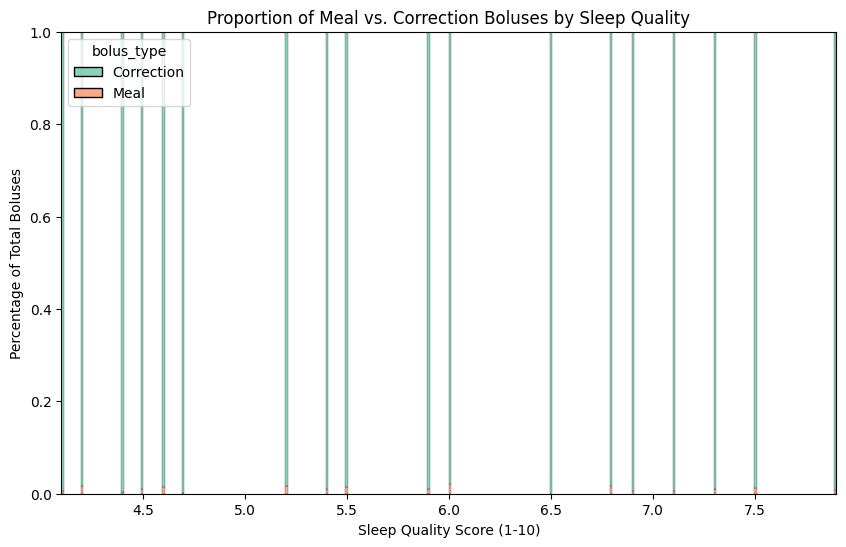

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# Step 1: Define a 'Correction' bolus as insulin taken when carbs are 0
df['bolus_type'] = df['carb_input'].apply(lambda x: 'Meal' if x > 0 else 'Correction')

# Step 2: Create a stacked bar chart to see the proportion
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='sleep_quality_(1-10)', hue='bolus_type', multiple='fill', palette='Set2')

# Formatting
plt.title('Proportion of Meal vs. Correction Boluses by Sleep Quality')
plt.xlabel('Sleep Quality Score (1-10)')
plt.ylabel('Percentage of Total Boluses')

plt.show()

<span style="color:green;">

##### **Key Insights:**
By analyzing the distribution of bolus types, we've diagnosed that Sleep Quality is a primary driver of treatment complexity. Poor sleep (scores 1-4) forces patients into a reactive 'Correction' state, while high-quality sleep (scores 8-10) allows for a proactive, meal-focused treatment plan. This proves that improving sleep quality can directly reduce the daily 'correction burden' for diabetic patients. </span>